In [14]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.special import logsumexp


In [22]:
title = 'Exp_1_live_lowpH'
#title = 'Exp_2_reduced_live_lowpH'
title = 'Exp_3_time-limited_lowpH'

input = f"grid_likelihood_outputs/{title}/grid_zomega.csv"
output = f"grid_likelihood_outputs/{title}/grid_zomega.png"


In [23]:
df = pd.read_csv(input)



In [24]:
df


,idx,alpha,mu,omega,loglike
0,0,0.0012,0.11,0.0,-inf
1,1,0.0024,0.11,0.0,-inf
2,2,0.0036,0.11,0.0,-inf
3,3,0.0048,0.11,0.0,-inf
4,4,0.0060,0.11,0.0,-inf
...,...,...,...,...,...
2495,2495,0.0552,0.60,0.0,-2427.866454
2496,2496,0.0564,0.60,0.0,-2434.834782
2497,2497,0.0576,0.60,0.0,-2438.560950
2498,2498,0.0588,0.60,0.0,-2449.262570


In [25]:
alphas = np.unique(df["alpha"].values)
mus = np.unique(df["mu"].values)


In [26]:
sh = (len(mus), len(alphas))
A = df["alpha"].values.reshape(sh)
M = df["mu"].values.reshape(sh)
Z = df["loglike"].values.reshape(sh)

Zeff = Z.clip(min = int(np.max(Z)-20))

Z_alpha = logsumexp(Z, axis=0) - logsumexp(Z)
Z_mu = logsumexp(Z, axis=1) - logsumexp(Z)


/tmp/ipykernel_74452/1998107021.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


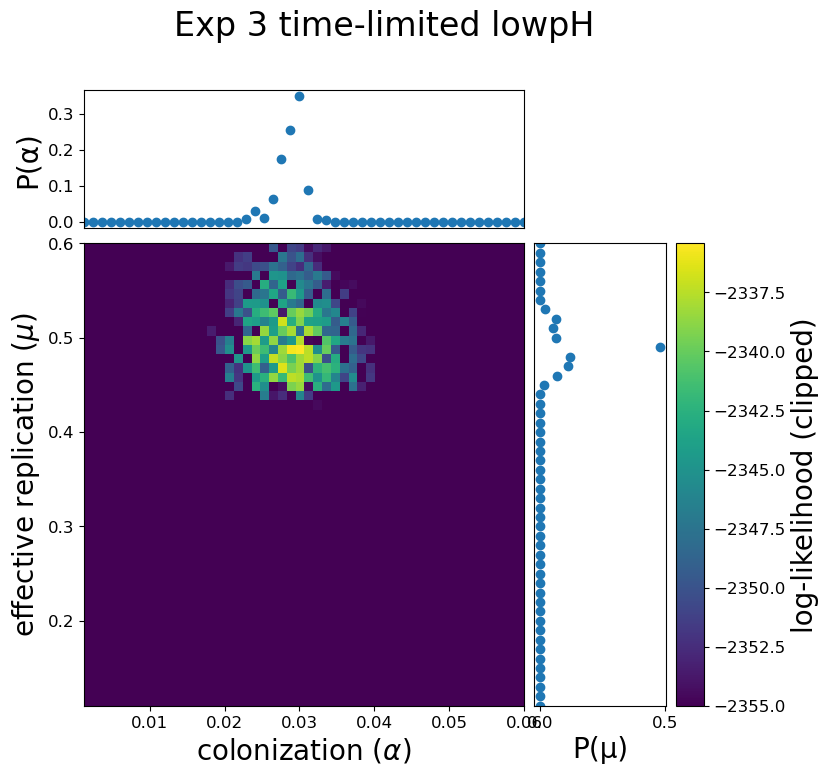

In [27]:
from matplotlib import gridspec
plt.rcParams.update({
    "font.size": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 20
})

P_alpha = np.exp(Z_alpha)
P_mu    = np.exp(Z_mu)
# --- layout ---
P_alpha = np.exp(Z_alpha)
P_mu    = np.exp(Z_mu)

# --- layout with dedicated colorbar column ---
fig = plt.figure(figsize=(8, 8))
gs = gridspec.GridSpec(
    2, 3,
    width_ratios=[4, 1.2, 0.25],   # extra column for colorbar
    height_ratios=[1.2, 4],
    hspace=0.05,
    wspace=0.05
)

ax_top    = fig.add_subplot(gs[0, 0])
ax_joint  = fig.add_subplot(gs[1, 0])
ax_right  = fig.add_subplot(gs[1, 1])
ax_cbar   = fig.add_subplot(gs[1, 2])  # colorbar axis

# --- joint heatmap ---
# im = ax_joint.pcolormesh(
#     alphas,
#     mus,
#     Zeff.T,
#     shading="auto"
# )
im = ax_joint.imshow(
    Zeff,
    extent=[alphas.min(), alphas.max(), mus.min(), mus.max()],
    aspect="auto",
    origin="lower"
)

ax_joint.set_xlabel(r"colonization ($\alpha$)")
ax_joint.set_ylabel(r"effective replication ($\mu$)")

# --- colorbar in dedicated axis ---
cbar = fig.colorbar(im, cax=ax_cbar)
cbar.set_label("log-likelihood (clipped)")

# --- top marginal ---
ax_top.scatter(alphas, P_alpha)
ax_top.set_xlim(ax_joint.get_xlim())
ax_top.set_xticks([])
ax_top.set_ylabel("P(α)")

# --- right marginal ---
ax_right.scatter(P_mu, mus)
ax_right.set_ylim(ax_joint.get_ylim())
ax_right.set_yticks([])
ax_right.set_xlabel("P(μ)")

plt.suptitle(title.replace("_", " "))
plt.tight_layout()

plt.savefig(output, dpi=500)


In [28]:
df[df["loglike"] == df["loglike"].max()]


,idx,alpha,mu,omega,loglike
1924,1924,0.03,0.49,0.0,-2335.425663
